In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
#df = pd.read_csv("Downloads/garch_volatility (1).csv")
df = pd.read_csv("Downloads/FInal_aggregated_dataset.csv")

In [3]:
df.columns

Index(['Date', 'index', 'volatility', 'Newscore', 'Newsenti', 'Tweetscore',
       'Tweetsenti', 'garch_volatility'],
      dtype='object')

In [4]:
le = LabelEncoder()
df["News Sentiment"] = le.fit_transform(df["Newsenti"].astype(str))
df["Tweets Sentiment"] = le.fit_transform(df["Tweetsenti"].astype(str))

In [5]:
df['vol_1'] = df['volatility'].shift(1)

In [6]:
X = df[["Newscore", "News Sentiment", "Tweetscore", "Tweets Sentiment",
        "index",'vol_1']]
y = df["volatility"]


In [7]:
 df = df.dropna()
X = X.loc[df.index]
y = y.loc[df.index]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.139969930010457
MAE: 0.051460335446458824
RMSE: 0.08168261818481053


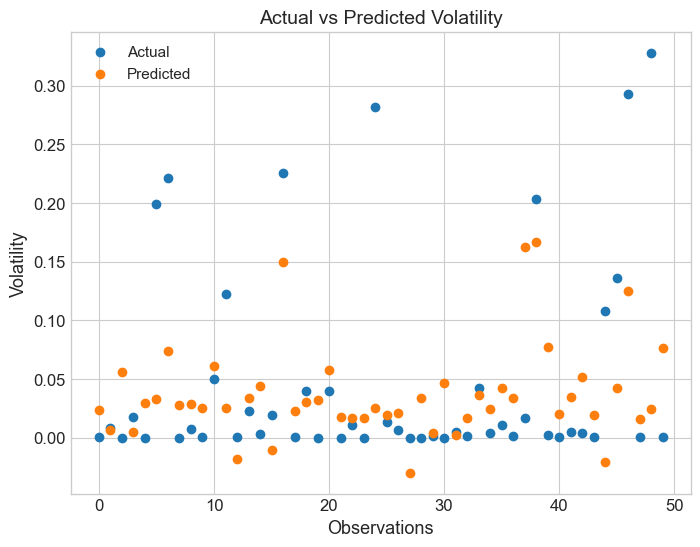

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (10, 6),
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})
plt.figure(figsize=(8,6))
# Actual values
plt.scatter(range(len(y_test)), y_test, label="Actual")
# Predicted values
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.xlabel("Observations")
plt.ylabel("Volatility")
plt.title("Actual vs Predicted Volatility")
plt.savefig("Actual vs Predicted Volatility.png", dpi=300)
plt.legend()
plt.show()

In [13]:
X = df[["Newscore", 'vol_1',"News Sentiment", "Tweetscore", 
        "Tweets Sentiment","index"]]
y = df["garch_volatility"]

In [14]:
df = df.dropna()
X = X.loc[df.index]
y = y.loc[df.index]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)


In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.20314719104744838
MAE: 5.497509216662459
RMSE: 10.940515370217682


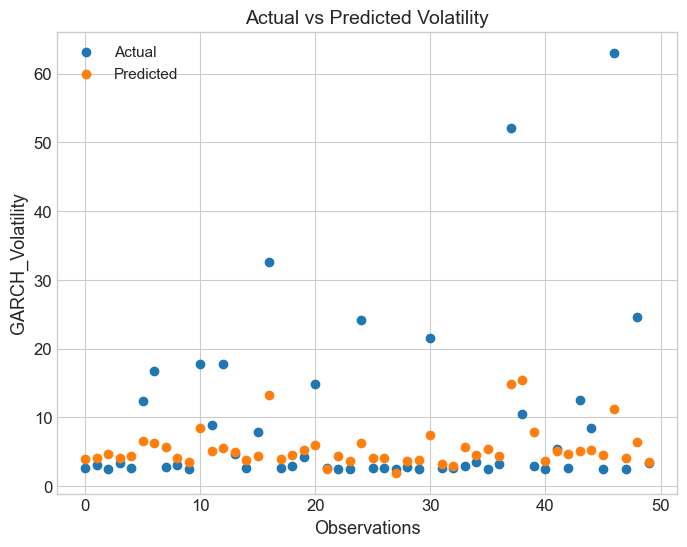

In [19]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (10, 6),
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})
plt.figure(figsize=(8,6))
# Actual values
plt.scatter(range(len(y_test)), y_test, label="Actual")
# Predicted values
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.xlabel("Observations")
plt.ylabel("GARCH_Volatility")
plt.title("Actual vs Predicted Volatility")
plt.savefig("Actual vs Predicted VolatilityGARCH.png", dpi=300)
plt.legend()
plt.show()

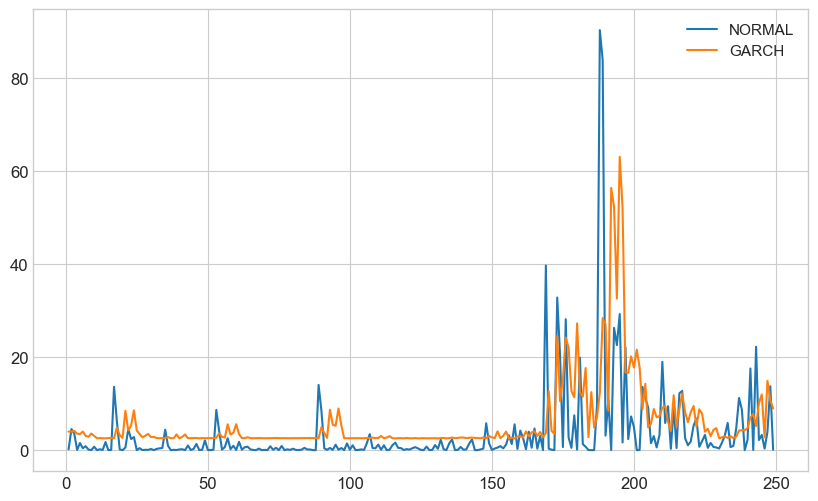

In [20]:
plt.plot(df['volatility']*100, label='NORMAL')
plt.plot(df['garch_volatility'], label='GARCH')
plt.savefig("Normal VS GARCH.png", dpi=300)
plt.legend()

In [21]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Sort by time (VERY IMPORTANT)
df = df.sort_values(by='Date')

Y = df['volatility']
X = df.drop(columns=['volatility','Date','garch_volatility','Newsenti','Tweetsenti'])

In [22]:
n = len(df)

splits = [
    int(0.83 * n),   # ~10 months
    int(0.92 * n),   # ~11 months
    int(0.96 * n),   # ~11.5 months
    int(0.98 * n)    # ~11.75 months
]

In [23]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    model = LinearRegression()
    model.fit(X_train, Y_train)

    preds = model.predict(X_test)
    
        # --- Metrics ---
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)
    # --- Directional Accuracy ---
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction_correct = np.sign(actual_diff) == np.sign(pred_diff)
    directional_accuracy = np.mean(direction_correct)
    
    results.append({
        "Split": i+1,
        "Train Size": split,
        "Test Size": len(Y_test),
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Directional Accuracy": directional_accuracy
    })
    
    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {directional_accuracy:.4f}
    """)

results_df = pd.DataFrame(results)


    Split 1
    Train Size: 206
    Test Size: 43
    MSE: 0.0024
    MAE: 0.0383
    R2: -0.7495
    Directional Accuracy: 0.6047
    

    Split 2
    Train Size: 229
    Test Size: 20
    MSE: 0.0014
    MAE: 0.0301
    R2: -2.0287
    Directional Accuracy: 0.5000
    

    Split 3
    Train Size: 239
    Test Size: 10
    MSE: 0.0008
    MAE: 0.0251
    R2: -0.0020
    Directional Accuracy: 0.5000
    

    Split 4
    Train Size: 244
    Test Size: 5
    MSE: 0.0007
    MAE: 0.0245
    R2: -180.5115
    Directional Accuracy: 0.6000
    


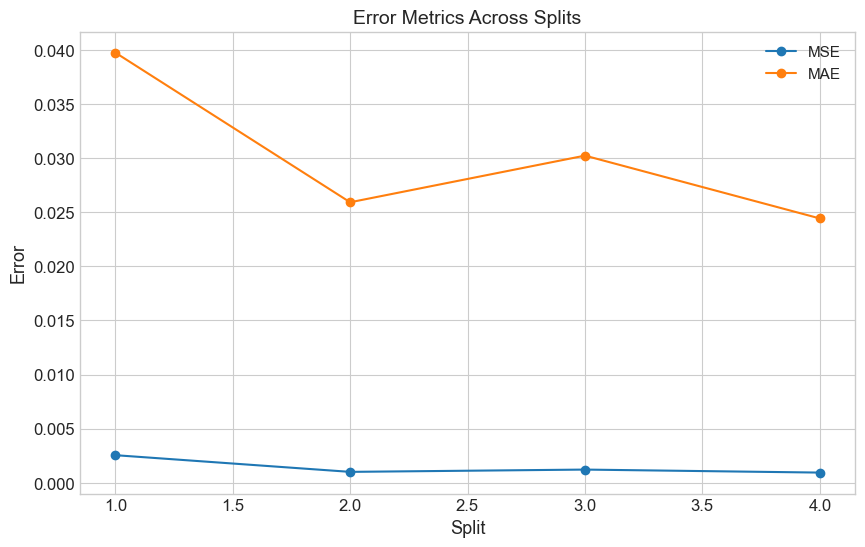

In [24]:
plt.figure()
plt.plot(results_df["Split"], results_df["MSE"], label="MSE", marker='o')
plt.plot(results_df["Split"], results_df["MAE"], label="MAE", marker='o')
plt.legend()
plt.title("Error Metrics Across Splits")
plt.xlabel("Split")
plt.ylabel("Error")
plt.show()

In [24]:
Y = df['garch_volatility']
X = df.drop(columns=[ 'Date','garch_volatility','Newsenti',	'Tweetsenti'])

In [25]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    model = LinearRegression()
    model.fit(X_train, Y_train)

    preds = model.predict(X_test)
    
        # --- Metrics ---
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)
    # --- Directional Accuracy ---
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction_correct = np.sign(actual_diff) == np.sign(pred_diff)
    directional_accuracy = np.mean(direction_correct)
    
    results.append({
        "Split": i+1,
        "Train Size": split,
        "Test Size": len(Y_test),
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Directional Accuracy": directional_accuracy
    })
    
    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {directional_accuracy:.4f}
    """)

results_df = pd.DataFrame(results)


    Split 1
    Train Size: 206
    Test Size: 43
    MSE: 9.3077
    MAE: 2.5872
    R2: 0.0902
    Directional Accuracy: 0.6512
    

    Split 2
    Train Size: 229
    Test Size: 20
    MSE: 7.6553
    MAE: 2.3240
    R2: -1.6199
    Directional Accuracy: 0.7000
    

    Split 3
    Train Size: 239
    Test Size: 10
    MSE: 8.1769
    MAE: 2.4258
    R2: -3.1029
    Directional Accuracy: 0.5000
    

    Split 4
    Train Size: 244
    Test Size: 5
    MSE: 11.8503
    MAE: 2.8482
    R2: -293.9315
    Directional Accuracy: 0.4000
    


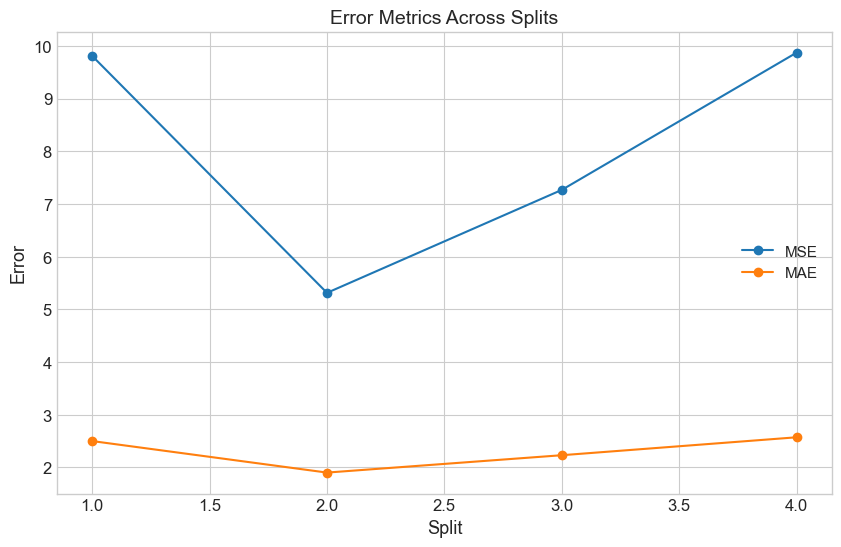

In [27]:
plt.figure()
plt.plot(results_df["Split"], results_df["MSE"], label="MSE", marker='o')
plt.plot(results_df["Split"], results_df["MAE"], label="MAE", marker='o')
plt.legend()
plt.title("Error Metrics Across Splits")
plt.xlabel("Split")
plt.ylabel("Error")
plt.show()

In [28]:
df.to_csv("Datasets.csv")

In [26]:
results_df = pd.DataFrame(results)

print(results_df)

   Split  Train Size  Test Size        MSE       MAE          R2  \
0      1         206         43   9.307709  2.587190    0.090199   
1      2         229         20   7.655303  2.323993   -1.619880   
2      3         239         10   8.176865  2.425789   -3.102872   
3      4         244          5  11.850284  2.848205 -293.931502   

   Directional Accuracy  
0              0.651163  
1              0.700000  
2              0.500000  
3              0.400000  
